In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("problem4.csv")

x1 = data["x1"].dropna()
x2 = data["x2"].dropna()

df = data[["x1", "x2"]].dropna()

# --------------------------------------------------
# Sample covariance matrix
# --------------------------------------------------
#
# pandas uses the sample covariance convention:
# denominator = n - 1

cov_matrix = df.cov()

print("Sample Covariance Matrix")
print(cov_matrix)

Sample Covariance Matrix
          x1        x2
x1  1.099875  1.696902
x2  1.696902  4.104749


Problem 4(c)
----------------------------------------
Mean of x1:                 -0.016714
Mean of x2:                 0.045288
Conditional mean slope:     1.542813
Conditional variance:       1.486746
Conditional std deviation:  1.219322


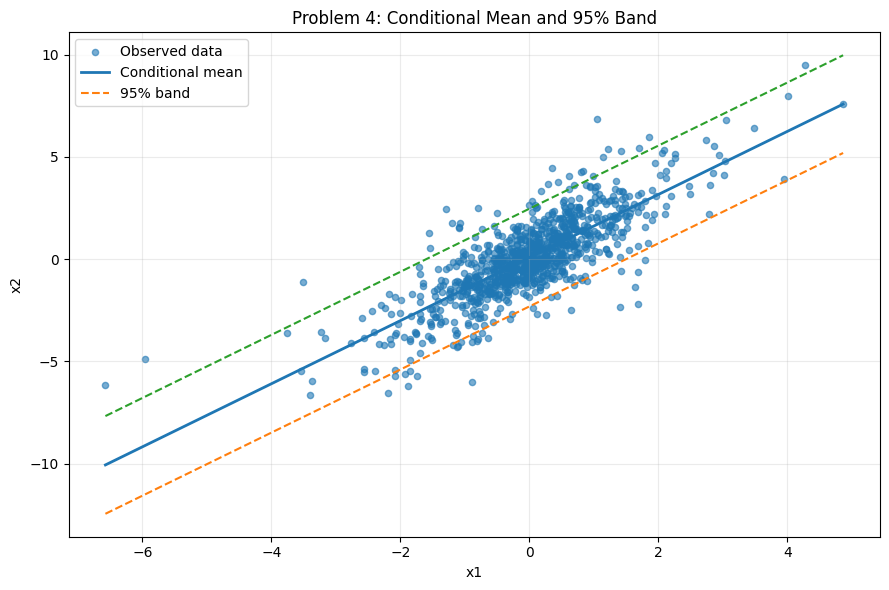

In [3]:
import matplotlib.pyplot as plt

data = pd.read_csv("problem4.csv")
df = data[["x1", "x2"]].dropna()

x1 = df["x1"]
x2 = df["x2"]

# --------------------------------------------------
# 1. Sample means
# --------------------------------------------------

mu1 = x1.mean()
mu2 = x2.mean()


# --------------------------------------------------
# 2. Sample covariance matrix
# --------------------------------------------------

cov_matrix = df.cov()

sigma11 = cov_matrix.loc["x1", "x1"]   # Var(X1)
sigma12 = cov_matrix.loc["x1", "x2"]   # Cov(X1, X2)
sigma21 = cov_matrix.loc["x2", "x1"]   # Cov(X2, X1)
sigma22 = cov_matrix.loc["x2", "x2"]   # Var(X2)


# --------------------------------------------------
# 3. Conditional mean coefficient
# --------------------------------------------------
#
# E[X2 | X1=x1]
#   = mu2 + beta * (x1 - mu1)
#
# beta = Sigma21 * Sigma11^(-1)
#      = Cov(X1,X2) / Var(X1)
#
# This is also the slope coefficient from simple
# linear regression of X2 on X1.

beta = sigma21 / sigma11


# --------------------------------------------------
# 4. Conditional variance
# --------------------------------------------------
#
# Under the multivariate Normal model:
#
# Var(X2 | X1)
#   = Sigma22 - Sigma21 Sigma11^(-1) Sigma12

conditional_variance = (
    sigma22
    - sigma21 * sigma12 / sigma11
)

conditional_sd = np.sqrt(conditional_variance)


# --------------------------------------------------
# 5. Conditional mean over observed X1 values
# --------------------------------------------------

conditional_mean = (
    mu2
    + beta * (x1 - mu1)
)


# --------------------------------------------------
# 6. 95% Normal conditional band
# --------------------------------------------------
#
# Under the model:
#
# X2 | X1=x1 ~ Normal(
#     conditional mean,
#     conditional variance
# )
#
# A 95% band is approximately:
#
# conditional mean +/- 1.96 * conditional SD

lower_band = conditional_mean - 1.96 * conditional_sd
upper_band = conditional_mean + 1.96 * conditional_sd


# --------------------------------------------------
# 7. Print numerical results
# --------------------------------------------------

print("Problem 4(c)")
print("----------------------------------------")
print(f"Mean of x1:                 {mu1:.6f}")
print(f"Mean of x2:                 {mu2:.6f}")
print(f"Conditional mean slope:     {beta:.6f}")
print(f"Conditional variance:       {conditional_variance:.6f}")
print(f"Conditional std deviation:  {conditional_sd:.6f}")


# --------------------------------------------------
# 8. Plot scatter + conditional expectation + band
# --------------------------------------------------
#
# Sort X1 only for drawing smooth ordered lines.

plot_df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "conditional_mean": conditional_mean,
    "lower_band": lower_band,
    "upper_band": upper_band
}).sort_values("x1")

plt.figure(figsize=(9, 6))

# Actual observations
plt.scatter(
    plot_df["x1"],
    plot_df["x2"],
    alpha=0.6,
    s=20,
    label="Observed data"
)

# Conditional expectation
plt.plot(
    plot_df["x1"],
    plot_df["conditional_mean"],
    linewidth=2,
    label="Conditional mean"
)

# 95% conditional band
plt.plot(
    plot_df["x1"],
    plot_df["lower_band"],
    linestyle="--",
    linewidth=1.5,
    label="95% band"
)

plt.plot(
    plot_df["x1"],
    plot_df["upper_band"],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Problem 4: Conditional Mean and 95% Band")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()


plt.show()

In [4]:
# Problem 4(d): Overall coverage of the 95% band

inside_band = (
    (x2 >= lower_band) &
    (x2 <= upper_band)
)

# Number of observations inside the band
n_inside = inside_band.sum()

# Total number of observations
n_total = len(df)

# Empirical coverage rate
coverage = n_inside / n_total

print("\nProblem 4(d)")
print(f"Observations inside band: {n_inside}")
print(f"Total observations:       {n_total}")
print(f"Overall coverage:         {coverage:.6f}")
print(f"Overall coverage (%):     {coverage * 100:.2f}%")


Problem 4(d)
Observations inside band: 935
Total observations:       1000
Overall coverage:         0.935000
Overall coverage (%):     93.50%


In [5]:
# Problem 4(e): Coverage by distance from mean of X1

# Sample standard deviation of X1
sd_x1 = x1.std(ddof=1)

# Measure how many standard deviations each X1
# observation is away from the sample mean.
distance_from_mean = np.abs(x1 - mu1) / sd_x1


bucket_1 = distance_from_mean < 1

bucket_2 = (
    (distance_from_mean >= 1) &
    (distance_from_mean < 2)
)

bucket_3 = distance_from_mean >= 2


# --------------------------------------------------
# Function to calculate coverage within each bucket
# --------------------------------------------------

def bucket_coverage(mask, name):

    # Number of observations belonging to this bucket
    n_bucket = mask.sum()

    # Number that also fall inside the 95% band
    n_inside_bucket = (inside_band & mask).sum()

    # Empirical coverage for this bucket
    coverage_bucket = n_inside_bucket / n_bucket

    print(f"\n{name}")
    print(f"Observations:       {n_bucket}")
    print(f"Inside 95% band:    {n_inside_bucket}")
    print(f"Coverage:           {coverage_bucket:.6f}")
    print(f"Coverage (%):       {coverage_bucket * 100:.2f}%")

    return coverage_bucket


print("\nProblem 4(e)")
print(f"Mean of x1: {mu1:.6f}")
print(f"SD of x1:   {sd_x1:.6f}")

coverage_1 = bucket_coverage(
    bucket_1,
    "|x1 - mean(x1)| < 1 SD"
)

coverage_2 = bucket_coverage(
    bucket_2,
    "1 SD <= |x1 - mean(x1)| < 2 SD"
)

coverage_3 = bucket_coverage(
    bucket_3,
    "|x1 - mean(x1)| >= 2 SD"
)


Problem 4(e)
Mean of x1: -0.016714
SD of x1:   1.048749

|x1 - mean(x1)| < 1 SD
Observations:       759
Inside 95% band:    726
Coverage:           0.956522
Coverage (%):       95.65%

1 SD <= |x1 - mean(x1)| < 2 SD
Observations:       190
Inside 95% band:    163
Coverage:           0.857895
Coverage (%):       85.79%

|x1 - mean(x1)| >= 2 SD
Observations:       51
Inside 95% band:    46
Coverage:           0.901961
Coverage (%):       90.20%
